In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('NASS_Bee-Colony_2015-2021.csv', low_memory=False)
df = df.dropna()

In [3]:
# Replacing NA values with np.nan and change the data types for multiple columns
cols = ['Starting Colonies','Maximum Colonies', 'Lost Colonies', 'Percent Loss', 'Added Colonies', 'Renovated Colonies','Percent Renovated']
df[cols] = df[cols].replace(['(NA)', '(X)', '(Z)'], np.nan)
df[cols] = df[cols].apply(pd.to_numeric)
print(df.dtypes)

State                     str
Starting Colonies     float64
Maximum Colonies      float64
Lost Colonies         float64
Percent Loss          float64
Added Colonies        float64
Renovated Colonies    float64
Percent Renovated     float64
Year                      str
dtype: object


In [4]:
missing_value = df.isna().sum()
print(missing_value)

State                   0
Starting Colonies      47
Maximum Colonies       72
Lost Colonies          47
Percent Loss           53
Added Colonies         47
Renovated Colonies     48
Percent Renovated     176
Year                    0
dtype: int64


In [5]:
#Statistics for each columns
print(df.describe().round(2))

       Starting Colonies  Maximum Colonies  Lost Colonies  Percent Loss  \
count            1175.00           1150.00        1175.00       1169.00   
mean           123280.66          79157.18       16970.03         11.59   
std            436620.40         190428.43       61636.84          7.31   
min              1300.00           1300.00           0.00          0.00   
25%              8000.00           9000.00         965.00          7.00   
50%             17500.00          21000.00        2200.00         10.00   
75%             55000.00          68000.00        7000.00         15.00   
max           3181180.00        1710000.00      502350.00         65.00   

       Added Colonies  Renovated Colonies  Percent Renovated  
count         1175.00             1174.00            1046.00  
mean         16660.37            14309.23               8.31  
std          66416.13            60490.39               9.60  
min              0.00                0.00               0.00  
25%      

In [6]:
df_states = df[df['State'] != "United States"].copy()
cols = ['Starting Colonies','Maximum Colonies', 'Lost Colonies', 'Percent Loss', 'Added Colonies', 'Renovated Colonies','Percent Renovated']
df_states[cols] = df[cols].apply(pd.to_numeric)
print(df_states.dtypes)


State                     str
Starting Colonies     float64
Maximum Colonies      float64
Lost Colonies         float64
Percent Loss          float64
Added Colonies        float64
Renovated Colonies    float64
Percent Renovated     float64
Year                      str
dtype: object


In [7]:
# Computing loss rate
df_states['loss_rate'] = np.where(df_states['Maximum Colonies'] > 0, (df_states['Lost Colonies']/df_states['Maximum Colonies']) *100, np.nan)

In [8]:
correlation = df_states['loss_rate'].corr(df_states['Percent Loss'].astype(float))
print(correlation)

0.9992694357551082


In [9]:
## What year was the loss rate at its worst?
national_by_year = (
    df_states
    .groupby('Year')['loss_rate']
    .mean()
    .reset_index()
    .rename(columns={'loss_rate': 'mean_loss_rate'})
    .sort_values('mean_loss_rate', ascending=False)
)


In [10]:
print("── National average colony loss rate by year ─────────────────")
print("   (Mean of all states, all quarters, that year)")
print()
print(national_by_year.to_string(index=False))

worst_year  = national_by_year.iloc[0]['Year']
worst_rate  = national_by_year.iloc[0]['mean_loss_rate']

# Filter out NaN values for 'mean_loss_rate' before finding the best year
best_year_df = national_by_year.dropna(subset=['mean_loss_rate'])
best_year   = best_year_df.iloc[-1]['Year']
best_rate   = best_year_df.iloc[-1]['mean_loss_rate']

print(f"\nWorst year : {int(worst_year.split('-')[0])}  ({worst_rate:.1f}% average loss)")
print(f"Best year  : {int(best_year.split('-')[0])}  ({best_rate:.1f}% average loss)")

── National average colony loss rate by year ─────────────────
   (Mean of all states, all quarters, that year)

   Year  mean_loss_rate
2015-Q1       17.873458
2018-Q1       16.336649
2017-Q1       15.067906
2016-Q1       13.708796
2018-Q4       13.401562
2019-Q1       12.471777
2017-Q3       12.377837
2021-Q1       12.374606
2017-Q4       12.111237
2020-Q3       11.829793
2019-Q4       11.748686
2020-Q1       11.393801
2015-Q3       11.291367
2018-Q3       11.071137
2019-Q3       11.057842
2016-Q3       11.044359
2016-Q4       10.977075
2020-Q4       10.945867
2015-Q4       10.220849
2018-Q2        8.773723
2015-Q2        8.684905
2016-Q2        8.548234
2020-Q2        8.123941
2021-Q2        8.103456
2017-Q2        7.064345
2019-Q2             NaN

Worst year : 2015  (17.9% average loss)
Best year  : 2017  (7.1% average loss)


In [11]:
# What states with the worst/best loss rate?
state_avg = (
    df_states
    .groupby('State')['loss_rate']
    .mean()
    .reset_index()
    .rename(columns={'loss_rate': 'mean_loss_rate'})
    .sort_values('mean_loss_rate', ascending=False)
)

In [12]:
print("── Average colony loss rate by state (2015–2022) ─────────────")
print()
print("Top 10 worst states:")
print(state_avg.head(10).to_string(index=False))

print("\nTop 10 best states (lowest loss):")
print(state_avg.tail(10).to_string(index=False))



── Average colony loss rate by state (2015–2022) ─────────────

Top 10 worst states:
     State  mean_loss_rate
    Kansas       19.541289
   Arizona       17.898271
New Mexico       17.503328
      Ohio       15.248331
   Alabama       15.177438
 Tennessee       15.158042
  Kentucky       14.803106
  Illinois       14.659223
  Arkansas       14.493338
  Colorado       14.245654

Top 10 best states (lowest loss):
       State  mean_loss_rate
South Dakota        8.811382
    Nebraska        8.737830
   Louisiana        7.701999
      Oregon        7.370361
North Dakota        7.193329
 Connecticut        7.127959
     Montana        5.938209
  New Jersey        5.571466
     Vermont        5.413375
      Hawaii        5.274100


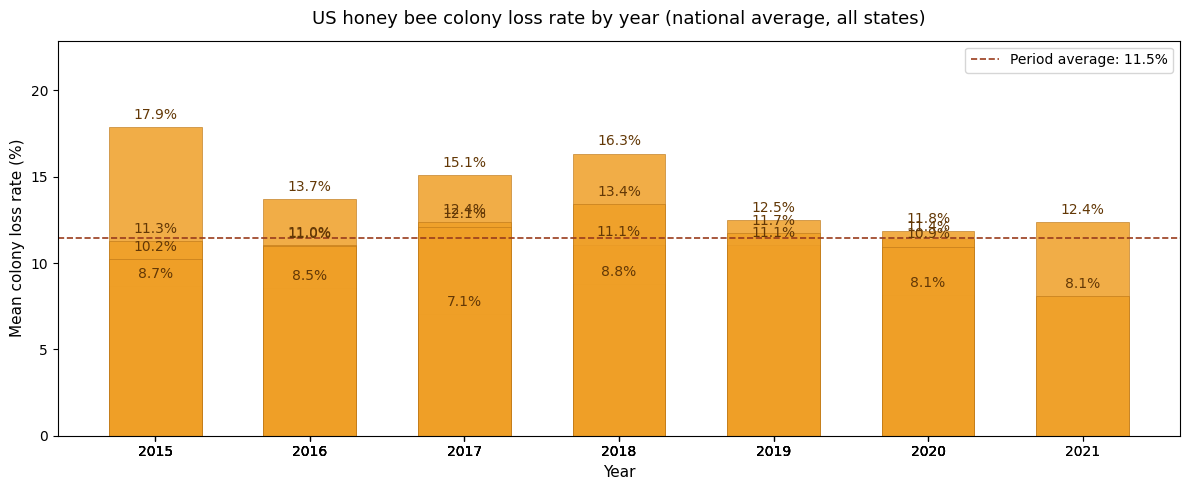

In [13]:
# CHART 1: National loss rate by year
national_by_year_sorted = national_by_year.sort_values('Year')

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    national_by_year_sorted['Year'].apply(lambda x: int(x.split('-')[0])),
    national_by_year_sorted['mean_loss_rate'],
    color='#EF9F27',    # Amber — fits the bee theme
    width=0.6,
    alpha=0.85,
    edgecolor='#BA7517',
    linewidth=0.5,
)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x = centre of bar
        height + 0.3,                         # y = just above bar
        f'{height:.1f}%',                     # text = formatted value
        ha='center', va='bottom',
        fontsize=10, color='#633806',
    )

# Add a reference line at the overall mean
overall_mean = national_by_year_sorted['mean_loss_rate'].mean()
ax.axhline(overall_mean, color='#993C1D', linestyle='--',
           linewidth=1.2, label=f'Period average: {overall_mean:.1f}%')

ax.set_title('US honey bee colony loss rate by year (national average, all states)',
             fontsize=13, pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean colony loss rate (%)', fontsize=11)
ax.set_xticks(national_by_year_sorted['Year'].apply(lambda x: int(x.split('-')[0])))
ax.legend(fontsize=10)
ax.set_ylim(0, national_by_year_sorted['mean_loss_rate'].max() + 5)

plt.tight_layout()
plt.savefig('day1_loss_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

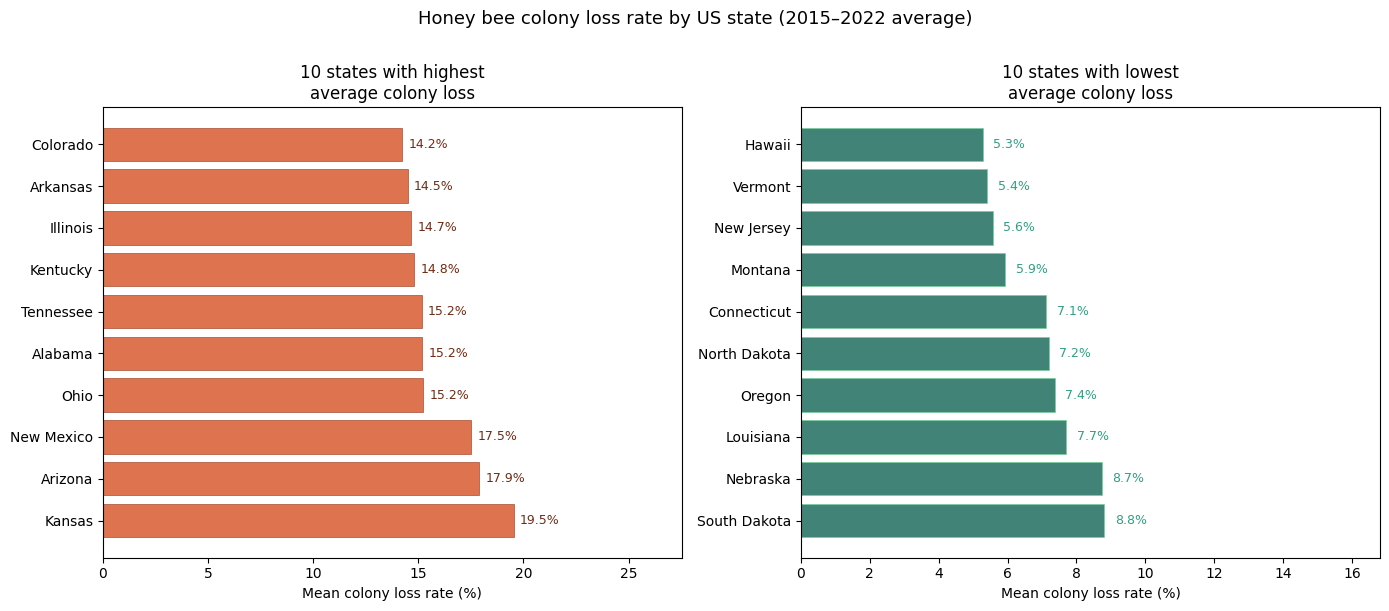

In [14]:
# CHART 2: Loss rate by states
worst_10_states = state_avg.head(10)
best_10_states = state_avg.tail(10)

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(
    worst_10_states['State'],
    worst_10_states['mean_loss_rate'],
    color = '#D85A30',
    alpha  = 0.85,
    edgecolor='#993C1D',
    linewidth=0.5,
)
for i, (val, name) in enumerate(zip(worst_10_states['mean_loss_rate'],
                                     worst_10_states['State'])):
    ax1.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9,
             color='#712B13')

ax1.set_title('10 states with highest\naverage colony loss', fontsize=12)
ax1.set_xlabel('Mean colony loss rate (%)')
ax1.set_xlim(0, worst_10_states['mean_loss_rate'].max() + 8)

ax2.barh(
    best_10_states["State"],
    best_10_states["mean_loss_rate"],
    color = '#1F6F5F',
    alpha = 0.85,
    edgecolor = '#6FCF97',
    linewidth=0.5,
)
for i, (val, name) in enumerate(zip(best_10_states['mean_loss_rate'],
                                     best_10_states['State'])):
  ax2.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9,color = '#2FA084')
ax2.set_title('10 states with lowest\naverage colony loss', fontsize=12)
ax2.set_xlabel('Mean colony loss rate (%)')
ax2.set_xlim(0, best_10_states['mean_loss_rate'].max() + 8)
plt.suptitle('Honey bee colony loss rate by US state (2015–2022 average)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('day1_loss_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

##Handling NA values

In [15]:
missing_value = df_states.isna().sum()
missing_pct = (missing_value/len(df)*100).round(1)
print(missing_pct)

State                  0.0
Starting Colonies      3.8
Maximum Colonies       3.8
Lost Colonies          3.8
Percent Loss           4.3
Added Colonies         3.8
Renovated Colonies     3.8
Percent Renovated     14.3
Year                   0.0
loss_rate              3.8
dtype: float64


In [16]:
df_clean = df_states.copy()

In [17]:
core_cols = ['Maximum Colonies', 'Percent Loss', 'loss_rate', 'Starting Colonies']
existing_core = [c for c in core_cols if c in df_clean.columns]
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=existing_core)
rows_dropped = rows_before - len(df_clean)

In [18]:
activity_cols = ['Added Colonies', 'Renovated Colonies', 'Pecent Renovated']
for col in activity_cols:
    if col in df_clean.columns:
        n_filled = df_clean[col].isna().sum()
        df_clean[col] = df_clean[col].fillna(0)
        if n_filled > 0:
            print(f"Filled {n_filled} missing values in '{col}' with 0")


Filled 1 missing values in 'Renovated Colonies' with 0


In [19]:
remaining = df_clean[existing_core].isna().sum()
print(remaining.to_string())

Maximum Colonies     0
Percent Loss         0
loss_rate            0
Starting Colonies    0


##Seasonal Analysis

In [20]:
print(df_clean["Year"].unique())
df_clean['quarter_label'] = df_clean['Year'].str.strip().str[-2:]
print(df_clean["quarter_label"].unique())

<StringArray>
['2015-Q1', '2015-Q2', '2015-Q3', '2015-Q4', '2016-Q1', '2016-Q2', '2016-Q3',
 '2016-Q4', '2017-Q1', '2017-Q2', '2017-Q3', '2017-Q4', '2018-Q1', '2018-Q2',
 '2018-Q3', '2018-Q4', '2019-Q1', '2019-Q3', '2019-Q4', '2020-Q1', '2020-Q2',
 '2020-Q3', '2020-Q4', '2021-Q1', '2021-Q2']
Length: 25, dtype: str
<StringArray>
['Q1', 'Q2', 'Q3', 'Q4']
Length: 4, dtype: str


In [21]:
Season_mapping = {
    'Q1': 'Winter',
    'Q2': 'Spring',
    'Q3': 'Summer',
    'Q4': 'Fall'
}
df_clean['Season'] = df_clean['quarter_label'].map(Season_mapping)
df_clean.head()


,State,Starting Colonies,Maximum Colonies,Lost Colonies,Percent Loss,Added Colonies,Renovated Colonies,Percent Renovated,Year,loss_rate,quarter_label,Season
0,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,Q1,Winter
1,Arizona,35000.0,35000.0,4600.0,13.0,3400.0,2100.0,6.0,2015-Q1,13.142857,Q1,Winter
2,Arkansas,13000.0,14000.0,1500.0,11.0,1200.0,90.0,1.0,2015-Q1,10.714286,Q1,Winter
3,California,1440000.0,1690000.0,255000.0,15.0,250000.0,124000.0,7.0,2015-Q1,15.088757,Q1,Winter
4,Colorado,3500.0,12500.0,1500.0,12.0,200.0,140.0,1.0,2015-Q1,12.000000,Q1,Winter


In [22]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# Calculate the mean and standard deviation of loss rate for each Season
seasonal_stats = (
    df_clean.groupby('Season')['loss_rate']
    .agg(['mean', 'std', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_loss_rate', 'std': 'std_loss_rate'})
)

# Convert the 'Season' column to a Categorical type with the defined order
seasonal_stats['Season'] = pd.Categorical(seasonal_stats['Season'], categories=season_order, ordered=True)

# Sort the DataFrame by the ordered 'Season' for chronological display
seasonal_stats = seasonal_stats.sort_values('Season')

print("Seasonal colony loss rate statistics ")
print(seasonal_stats.to_string(index=False))
print()

# Find the worst and best seasons based on 'mean_loss_rate'
# Sort by mean_loss_rate to identify highest/lowest
worst_season_df = seasonal_stats.sort_values('mean_loss_rate', ascending=False)
worst_season = worst_season_df.iloc[0]['Season']
best_season = worst_season_df.iloc[-1]['Season']

print(f"Highest average loss: {worst_season}")
print(f"Lowest average loss : {best_season}")

Seasonal colony loss rate statistics 
Season  mean_loss_rate  std_loss_rate    median  count
Winter       14.350696       9.321414 12.727273    318
Spring        8.245193       5.464726  7.647059    275
Summer       11.445389       6.062143 10.529825    276
  Fall       11.608819       6.284100 11.000000    275

Highest average loss: Winter
Lowest average loss : Spring


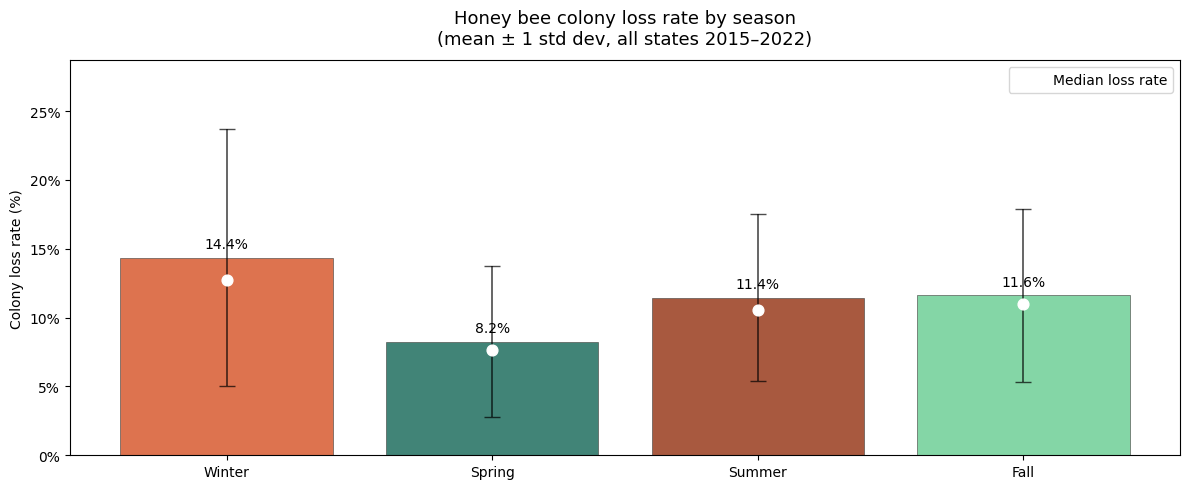

In [23]:
import matplotlib.ticker as mticker

Season_color = {
    'Winter' : '#D85A30',
    'Spring' : '#1F6F5F',
    'Summer' : '#993C1D',
    'Fall'   : '#6FCF97'
}
fig, ax = plt.subplots(figsize=(12,5))
colors = [Season_color[s] for s in seasonal_stats['Season']]

bars = ax.bar(
    seasonal_stats['Season'],
    seasonal_stats['mean_loss_rate'],
    yerr=seasonal_stats['std_loss_rate'],    # Error bars = ± 1 standard deviation, Corrected column name
    color=colors,
    alpha=0.85,
    edgecolor='#444441',
    linewidth=0.5,
    capsize=6,
    error_kw={'linewidth': 1.2, 'alpha': 0.7},
)


ax.scatter(
    seasonal_stats['Season'],
    seasonal_stats['median'],
    color='white', s=60, zorder=5,
    label='Median loss rate',
)

# Add mean value labels above each bar
for bar, val in zip(bars, seasonal_stats['mean_loss_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + seasonal_stats['std_loss_rate'].max() * 0.05,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='500',
    )

ax.set_title('Honey bee colony loss rate by season\n(mean ± 1 std dev, all states 2015–2022)',
             fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Colony loss rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(fontsize=10)
ax.set_ylim(0, seasonal_stats['mean_loss_rate'].max() + seasonal_stats['std_loss_rate'].max() + 5)

plt.tight_layout()
plt.savefig('day2_seasonal_loss.png', dpi=150, bbox_inches='tight')
plt.show()

##Regional Analysis

In [24]:
df_clean['State'].unique()


<StringArray>
[       'Alabama',        'Arizona',       'Arkansas',     'California',
       'Colorado',    'Connecticut',        'Florida',        'Georgia',
         'Hawaii',          'Idaho',       'Illinois',        'Indiana',
           'Iowa',         'Kansas',       'Kentucky',      'Louisiana',
          'Maine',       'Maryland',  'Massachusetts',       'Michigan',
      'Minnesota',    'Mississippi',       'Missouri',        'Montana',
       'Nebraska',     'New Jersey',     'New Mexico',       'New York',
 'North Carolina',   'North Dakota',           'Ohio',       'Oklahoma',
         'Oregon',   'Pennsylvania', 'South Carolina',   'South Dakota',
      'Tennessee',          'Texas',           'Utah',        'Vermont',
       'Virginia',     'Washington',  'West Virginia',      'Wisconsin',
        'Wyoming',          'Other']
Length: 46, dtype: str

In [25]:
regional_mapping = {
    'Alabama': 'South',
    'Arizona': 'West',
    'Arkansas': 'South',
    'California': 'West',
    'Colorado': 'West',
    'Connecticut': 'Northeast',
    'Florida': 'South',
    'Georgia': 'South',
    'Hawaii': 'West',
    'Idaho': 'West',
    'Illinois': 'Midwest',
    'Indiana': 'Midwest',
    'Iowa': 'Midwest',
    'Kansas': 'Midwest',
    'Kentucky': 'South',
    'Louisiana': 'South',
    'Maine': 'Northeast',
    'Maryland': 'South',
    'Massachusetts': 'Northeast',
    'Michigan': 'Midwest',
    'Minnesota': 'Midwest',
    'Mississippi': 'South',
    'Missouri': 'Midwest',
    'Montana': 'West',
    'Nebraska': 'Midwest',
    'Nevada': 'West',
    'New Hampshire': 'Northeast',
    'New Jersey': 'Northeast',
    'New Mexico': 'West',
    'New York': 'Northeast',
    'North Carolina': 'South',
    'North Dakota': 'Midwest',
    'Ohio': 'Midwest',
    'Oklahoma': 'South',
    'Oregon': 'West',
    'Pennsylvania': 'Northeast',
    'Rhode Island': 'Northeast',
    'South Carolina': 'South',
    'South Dakota': 'Midwest',
    'Tennessee': 'South',
    'Texas': 'South',
    'Utah': 'West',
    'Vermont': 'Northeast',
    'Virginia': 'South',
    'Washington': 'West',
    'West Virginia': 'South',
    'Wisconsin': 'Midwest',
    'Wyoming': 'West',
    'Other': 'Other' # Handle the 'Other' category if it exists in your data
}

df_clean['Region'] = df_clean['State'].map(regional_mapping)

print(df_clean[['State', 'Region']].head())
print(df_clean['Region'].unique())


        State Region
0     Alabama  South
1     Arizona   West
2    Arkansas  South
3  California   West
4    Colorado   West
<StringArray>
['South', 'West', 'Northeast', 'Midwest', 'Other']
Length: 5, dtype: str


In [26]:
region_order = ['Northeast', 'Midwest', 'South', 'West', 'Other']
regional_stats = (
df_clean.groupby('Region')['loss_rate']
.agg(['mean', 'std', 'median', 'count'])
.reset_index()
.rename(columns={'mean': 'mean_loss_rate', 'std': 'std_loss_rate'}))
regional_stats['Region'] = pd.Categorical(regional_stats['Region'], categories=region_order, ordered=True)
regional_stats = regional_stats.sort_values(by='Region')
regional_stats.head()

,Region,mean_loss_rate,std_loss_rate,median,count
1,Northeast,9.120467,7.175652,7.500000,174
0,Midwest,12.203662,8.078630,10.396040,299
3,South,12.434215,6.682996,11.600000,373
4,West,11.040496,7.289665,9.857143,273
2,Other,11.777129,7.103508,10.700000,25


In [27]:
worst_region_loss = regional_stats.sort_values('mean_loss_rate', ascending=False).iloc[0]['Region']
best_region_loss = regional_stats.sort_values('mean_loss_rate').iloc[0]['Region']
print(f"Highest average loss: {worst_region_loss}")
print(f"Lowest average loss : {best_region_loss}")

Highest average loss: South
Lowest average loss : Northeast


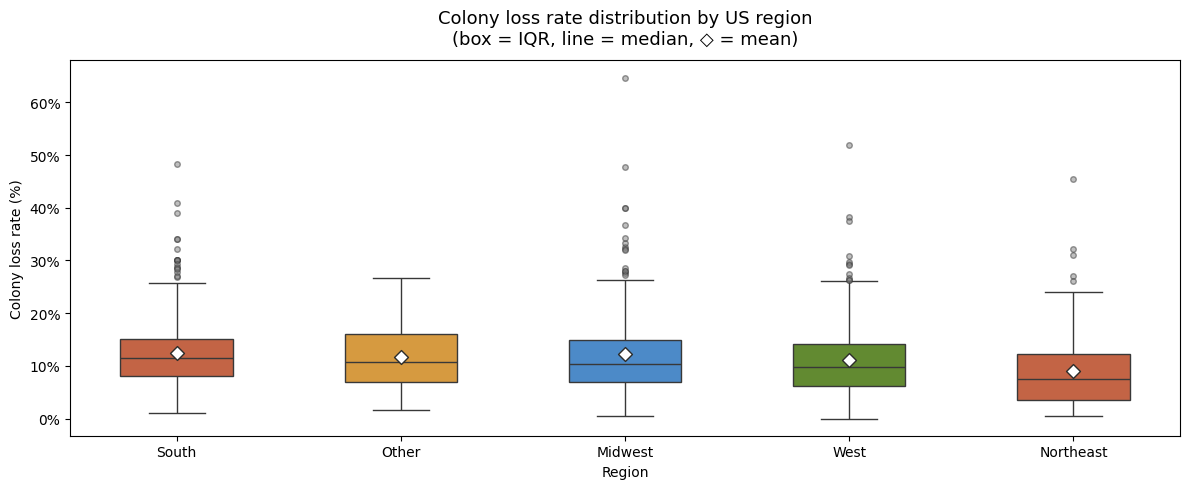

In [28]:
fig, ax = plt.subplots(figsize=(12,5))
region_order = (
    df_clean.groupby('Region')['loss_rate']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

sns.boxplot(
    data=df_clean,
    x='Region',
    y='loss_rate',
    order=region_order,
    palette=['#D85A30', '#EF9F27', '#378ADD', '#639922'],
    width=0.5,
    linewidth=1,
    flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=4, alpha=0.5),
    ax=ax,
)

region_means = df_clean.groupby('Region')['loss_rate'].mean()
for i, region in enumerate(region_order):
    ax.scatter(i, region_means[region], marker='D',
               color='white', s=50, zorder=5, linewidths=1,
               edgecolors='#2C2C2A')

ax.set_title('Colony loss rate distribution by US region\n(box = IQR, line = median, ◇ = mean)',
             fontsize=13, pad=12)
ax.set_xlabel('Region')
ax.set_ylabel('Colony loss rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.tight_layout()
plt.savefig('day2_regional_loss.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
df_clean['year_extract'] = df_clean['Year'].str.extract(r'(\d{4})')
seasonal_trend = (
    df_clean
    .groupby(['year_extract', 'Season'])['loss_rate']
    .mean()
    .reset_index()
)
pivot_trend = seasonal_trend.pivot(
    index='year_extract',
    columns='Season',
    values='loss_rate'
)
pivot_trend = pivot_trend.reindex(season_order, axis=1)
pivot_trend.head()

Season,Winter,Spring,Summer,Fall
year_extract,,,,
2015,17.873458,8.684905,11.291367,10.220849
2016,13.708796,8.731357,11.044359,10.977075
2017,15.067906,7.064345,12.377837,12.375544
2018,16.694501,8.773723,11.071137,13.401562
2019,12.746907,NaN,11.057842,11.748686


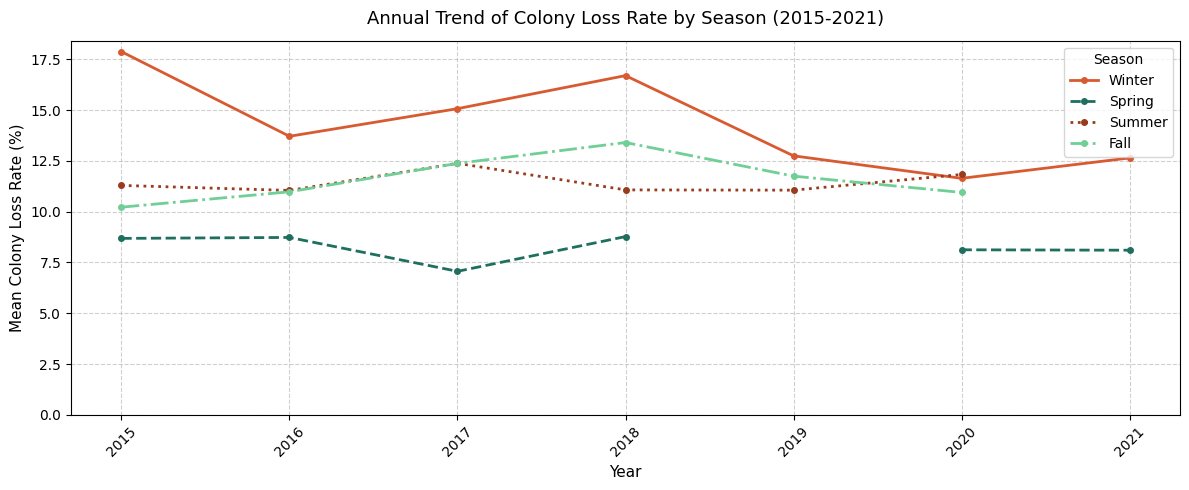

In [30]:
fig, ax = plt.subplots(figsize=(12,5))

line_styles = {'Winter': '-', 'Spring': '--', 'Summer': ':', 'Fall': '-.'}
colors = {'Winter': '#D85A30', 'Spring': '#1F6F5F', 'Summer': '#993C1D', 'Fall': '#6FCF97'}

for season in season_order:
    ax.plot(pivot_trend.index, pivot_trend[season], label=season,
            linestyle=line_styles.get(season, '-'), color=colors.get(season, 'black'),
            marker='o', markersize=4, linewidth=2)

ax.set_title('Annual Trend of Colony Loss Rate by Season (2015-2021)', fontsize=13, pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean Colony Loss Rate (%)', fontsize=11)
ax.legend(title='Season', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(bottom=0)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('day2_seasonal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis of Seasonal Trends in Colony Loss Rate

The line plot above illustrates the mean colony loss rate for each season (Winter, Spring, Summer, Fall) over the years 2015-2021. Several key observations can be drawn from this trend:

*   **Winter has consistently the highest loss rate:** This is expected as bees face significant challenges during colder months, including food scarcity, harsh weather, and increased susceptibility to diseases.

*   **Spring has the lowest loss rate:** This period generally marks the beginning of blooming flowers and increased food availability, allowing colonies to rebound and grow.

*   **Relatively stable trends for Summer and Fall:** 'Summer' and 'Fall' loss rates tend to fall between Winter and Spring, often showing more moderate fluctuations.

*   **Overall Fluctuations:** While the seasonal patterns are clear, there are year-to-year variations within each season. For instance, some years show slightly higher or lower loss rates within a given season compared to others. This could be attributed to varying environmental conditions, disease prevalence, or beekeeping practices in those specific years.

*   **No clear long-term improvement or decline within this period:** For the observed period (2015-2021), there isn't a strong indication of a sustained, significant decrease or increase in colony loss rates for any particular season. The trends appear relatively stable, oscillating around a mean for each season.

## STRESSOR CORRELATION MATRIX

In [31]:
df_stressor = pd.read_csv('NASS_Bee-Stressors_2015-2021.csv', low_memory=False)

In [32]:
print('df_stressor info:')
df_stressor.info()

df_stressor['year_extract'] = df_stressor['Year'].str.extract(r'(\d{4})')

print('\nStressors DataFrame head after year extraction:')
display(df_stressor.head())

df_stressor info:
<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   State                                1175 non-null   str  
 1   Varroa Mites (Percent)               1175 non-null   str  
 2   Other pests and parasites (Percent)  1175 non-null   str  
 3   Diseases (percent)                   1175 non-null   str  
 4   Pesticides (percent)                 1175 non-null   str  
 5   Other (percent)                      1175 non-null   str  
 6   Unknown (percent)                    1175 non-null   str  
 7   Year                                 1175 non-null   str  
dtypes: str(8)
memory usage: 73.6 KB

Stressors DataFrame head after year extraction:


,State,Varroa Mites (Percent),Other pests and parasites (Percent),Diseases (percent),Pesticides (percent),Other (percent),Unknown (percent),Year,year_extract
0,Alabama,10,5.4,(Z),2.2,9.1,9.4,2015-Q1,2015
1,Arizona,26.9,20.5,0.1,(Z),1.8,3.1,2015-Q1,2015
2,Arkansas,17.6,11.4,1.5,3.4,1,1,2015-Q1,2015
3,California,24.7,7.2,3,7.5,6.5,2.8,2015-Q1,2015
4,Colorado,14.6,0.9,1.8,0.6,2.6,5.9,2015-Q1,2015


In [33]:
df_merged = pd.merge(df_clean, df_stressor, on=['State', 'year_extract'], how='inner', suffixes=('_colony', '_stressor'))

print('Merged DataFrame head:')
display(df_merged.head())

Merged DataFrame head:


,State,Starting Colonies,Maximum Colonies,Lost Colonies,Percent Loss,Added Colonies,Renovated Colonies,Percent Renovated,Year_colony,loss_rate,...,Season,Region,year_extract,Varroa Mites (Percent),Other pests and parasites (Percent),Diseases (percent),Pesticides (percent),Other (percent),Unknown (percent),Year_stressor
0,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,...,Winter,South,2015,10,5.4,(Z),2.2,9.1,9.4,2015-Q1
1,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,...,Winter,South,2015,16.7,42.5,(Z),2.3,3.2,4.1,2015-Q2
2,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,...,Winter,South,2015,63.1,70.6,(Z),2.6,2.2,17.7,2015-Q3
3,Alabama,7000.0,7000.0,1800.0,26.0,2800.0,250.0,4.0,2015-Q1,25.714286,...,Winter,South,2015,3.1,6.4,0.2,0.2,2.8,1.9,2015-Q4
4,Arizona,35000.0,35000.0,4600.0,13.0,3400.0,2100.0,6.0,2015-Q1,13.142857,...,Winter,West,2015,26.9,20.5,0.1,(Z),1.8,3.1,2015-Q1


In [34]:
print(f"Shape of merged DataFrame: {df_merged.shape}")

print('\nMissing values in merged DataFrame:')
print(df_merged.isna().sum().sort_values(ascending=False).head(10))

Shape of merged DataFrame: (4303, 21)

Missing values in merged DataFrame:
Percent Renovated     485
Starting Colonies       0
Maximum Colonies        0
Lost Colonies           0
State                   0
Percent Loss            0
Added Colonies          0
Renovated Colonies      0
Year_colony             0
loss_rate               0
dtype: int64


In [35]:
stressor_cols = [
    'Varroa Mites (Percent)', 'Other pests and parasites (Percent)',
    'Diseases (percent)', 'Pesticides (percent)', 'Other (percent)',
    'Unknown (percent)'
]

# Convert stressor columns to numeric, coercing errors
for col in stressor_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

print('Stressor columns dtypes after conversion:')
print(df_merged[stressor_cols].dtypes)

Stressor columns dtypes after conversion:
Varroa Mites (Percent)                 float64
Other pests and parasites (Percent)    float64
Diseases (percent)                     float64
Pesticides (percent)                   float64
Other (percent)                        float64
Unknown (percent)                      float64
dtype: object


In [36]:
correlation_data = df_merged[['loss_rate'] + stressor_cols]

correlation_matrix = correlation_data.corr()

print('\nCorrelation Matrix:')
display(correlation_matrix)


Correlation Matrix:


,loss_rate,Varroa Mites (Percent),Other pests and parasites (Percent),Diseases (percent),Pesticides (percent),Other (percent),Unknown (percent)
loss_rate,1.000000,0.128176,0.031840,0.090428,0.090106,0.124075,0.113403
Varroa Mites (Percent),0.128176,1.000000,0.542471,0.333851,0.432163,0.299778,0.157045
Other pests and parasites (Percent),0.031840,0.542471,1.000000,0.230517,0.315573,0.203987,0.180255
Diseases (percent),0.090428,0.333851,0.230517,1.000000,0.322930,0.277532,0.084568
Pesticides (percent),0.090106,0.432163,0.315573,0.322930,1.000000,0.347900,0.185499
Other (percent),0.124075,0.299778,0.203987,0.277532,0.347900,1.000000,0.214637
Unknown (percent),0.113403,0.157045,0.180255,0.084568,0.185499,0.214637,1.000000


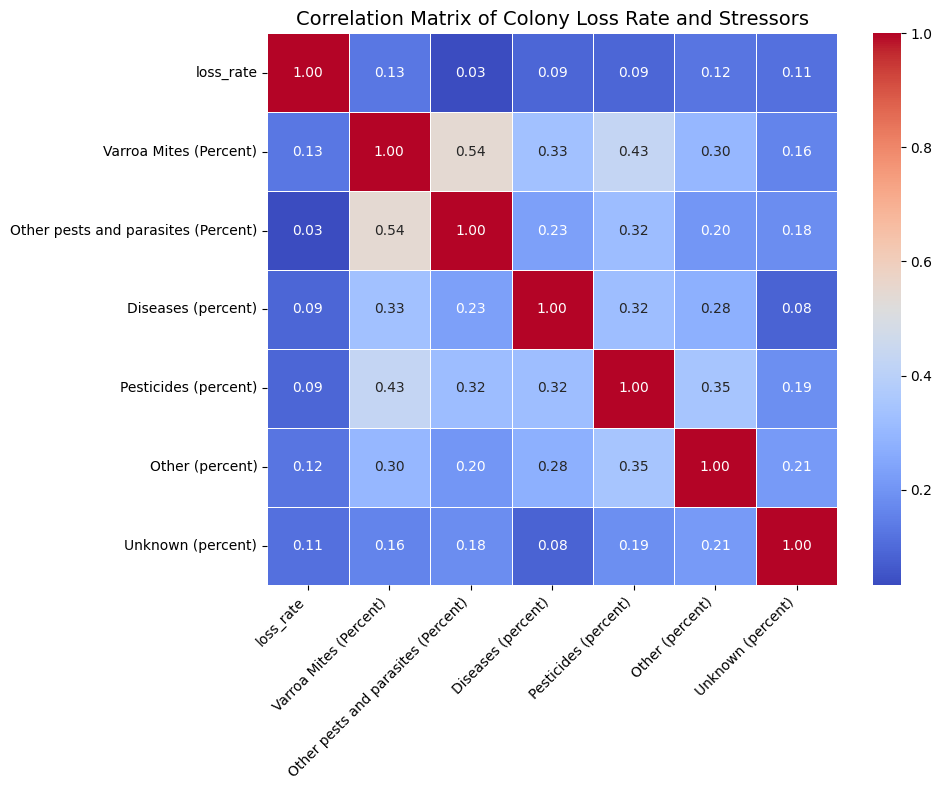

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Colony Loss Rate and Stressors', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('day3_stressor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
from scipy import stats
for s in stressor_cols:
  temp = df_merged[[s, 'loss_rate']].dropna()
  r,p = stats.pearsonr(temp[s], temp['loss_rate'])
  sig = '*' if p < 0.05 else ''
  print(f'{s}: r = {r:.2f} {sig}')


Varroa Mites (Percent): r = 0.13 *
Other pests and parasites (Percent): r = 0.03 *
Diseases (percent): r = 0.09 *
Pesticides (percent): r = 0.09 *
Other (percent): r = 0.12 *
Unknown (percent): r = 0.11 *


- Varroa Mites shows the strongest correlation with colony_loss (0.13) meaning states with higher verroa infection rates consistently lose more colony.
- Pest and parasites presence shows the weakest positive correlation (r = 0.03) showing a small but statistically significant relationship with colony loss.
-

## Regression model

In [39]:
features = stressor_cols
target = 'loss_rate'
model_df = df_merged[features + [target]].dropna()
X = model_df[features]
y = model_df[target]



In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (2700, 6)
Testing data shape: (676, 6)


In [41]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [42]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {mse:.2f}")


R-squared: 0.02
Mean Absolute Error: 5.24
Root Mean Squared Error: 6.96


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest R²  : {r2_score(y_test, y_pred_rf):.3f}")
print(f"Random Forest MAE : {mean_absolute_error(y_test, y_pred_rf):.2f}%")

# Feature importance — more reliable than linear coefficients
importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_df)

Random Forest R²  : -0.292
Random Forest MAE : 5.93%
                               feature  importance
0               Varroa Mites (Percent)    0.209018
1  Other pests and parasites (Percent)    0.164760
4                      Other (percent)    0.161254
5                    Unknown (percent)    0.160327
2                   Diseases (percent)    0.159979
3                 Pesticides (percent)    0.144661
